<a href="https://colab.research.google.com/github/jlvi179/Advanced-Deep-Learning/blob/main/Submission3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
!pip install git+https://github.com/thoglu/jammy_flows.git --no-deps

  Cloning https://github.com/thoglu/jammy_flows.git to /tmp/pip-req-build-ee0ur2_n
  Running command git clone --filter=blob:none --quiet https://github.com/thoglu/jammy_flows.git /tmp/pip-req-build-ee0ur2_n
  Resolved https://github.com/thoglu/jammy_flows.git to commit 3ec7872f8535b8e8db2e31f74a7c55bad5c54d5f
  Preparing metadata (setup.py) ... done


In [9]:
import time
import sys
import os
import argparse
import glob
import subprocess
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from matplotlib import pyplot as plt
import jammy_flows
from scipy.stats import norm
from huggingface_hub import hf_hub_download
import copy
import matplotlib.image as mpimg


# Helper Functions from helper.py

def normalize(labels, p):
    ranges = np.percentile(labels, [100 * p, 100 * (1 - p)], axis=0)
    labels = (labels - ranges[0]) / (ranges[1] - ranges[0])
    return labels, ranges

def denormalize(labels, ranges):
    return labels * (ranges[1] - ranges[0]) + ranges[0]

def denormalize_std(uncertainty, ranges):
    return uncertainty * (ranges[1] - ranges[0])

def get_normalized_data(data_path, return_SNR=False):
    spectra = np.load(f"{data_path}/spectra.npy")
    spectra_length = spectra.shape[1]
    labelNames = ["mass", "age", "l_bol", "dist", "t_eff", "log_g", "fe_h"]
    labels = np.load(f"{data_path}/labels.npy")
    labels = labels[:, :-1]
    labelNames = labelNames[-3:]
    labels = labels[:, -3:]
    n_labels = labels.shape[1]
    labels, ranges = normalize(labels, 0.05)
    spectra = np.log(np.maximum(spectra, 0.2))
    return spectra, labels, spectra_length, n_labels, labelNames, ranges

def ensure_data_downloaded(data_path):
    os.makedirs(data_path, exist_ok=True)
    for filename in ("labels.npy", "spectra.npy"):
        target_file = os.path.join(data_path, filename)
        if not os.path.exists(target_file):
            hf_hub_download(repo_id="simbaswe/galah4", filename=filename, repo_type="dataset", local_dir=data_path)

def train_model(model, train_loader, val_loader, loss_function, learning_rate, num_epochs, patience, device):
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    patience_counter = 0
    best_model = None
    for epoch in range(num_epochs):
        model.train()
        total_train_loss = 0.0
        for batch_spectra, batch_labels in train_loader:
            batch_spectra, batch_labels = batch_spectra.to(device).unsqueeze(1), batch_labels.to(device)
            optimizer.zero_grad()
            loss = loss_function(batch_spectra, batch_labels, model)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_train_loss += loss.item()
        model.eval()
        total_val_loss = 0.0
        with torch.no_grad():
            for batch_spectra, batch_labels in val_loader:
                batch_spectra, batch_labels = batch_spectra.to(device).unsqueeze(1), batch_labels.to(device)
                val_loss = loss_function(batch_spectra, batch_labels, model)
                total_val_loss += val_loss.item()
        avg_train_loss, avg_val_loss = total_train_loss / len(train_loader), total_val_loss / len(val_loader)
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss, patience_counter = avg_val_loss, 0
            best_model = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            if patience_counter > patience:
                print("Early stopping triggered.")
                break
    return train_losses, val_losses, best_model

def evaluate_model(model, test_loader, loss_function, device):
    model.eval()
    all_preds, all_truth, all_inputs = [], [], []
    with torch.no_grad():
        for batch_spectra, batch_labels in test_loader:
            batch_spectra, batch_labels = batch_spectra.to(device).unsqueeze(1), batch_labels.to(device)
            predictions = model(batch_spectra)
            all_preds.append(predictions.cpu())
            all_truth.append(batch_labels.cpu())
            all_inputs.append(batch_spectra.cpu())
    return torch.cat(all_preds).numpy(), torch.cat(all_truth).numpy(), torch.cat(all_inputs), None

class TinyCNNEncoder(nn.Module):
    def __init__(self, latent_dimension, input_length=16384):
        super(TinyCNNEncoder, self).__init__()
        self.model = nn.Sequential(
            nn.Conv1d(1, 10, kernel_size=5),
            nn.ReLU(),
            nn.BatchNorm1d(10),
            nn.AvgPool1d(3),
            nn.Conv1d(10, 20, kernel_size=5),
            nn.ReLU(),
            nn.BatchNorm1d(20),
            nn.AvgPool1d(3),
            nn.Conv1d(20, 40, kernel_size=5),
            nn.ReLU(),
            nn.BatchNorm1d(40),
            nn.AvgPool1d(3),
            nn.Conv1d(40, 10, kernel_size=1),
            nn.ReLU(),
            nn.BatchNorm1d(10),
            nn.AvgPool1d(2),
            nn.Conv1d(10, 12, kernel_size=3),
            nn.ReLU(),
            nn.BatchNorm1d(12),
            nn.Conv1d(12, 10, kernel_size=1)
        )
        with torch.no_grad():
            dummy_out = self.model(torch.zeros(1, 1, input_length))
            self.flatten_size = dummy_out.numel()
        self.fc = nn.Sequential(nn.Linear(self.flatten_size, 128), nn.ReLU(), nn.Linear(128, latent_dimension))
    def forward(self, x):
        x = self.model(x)
        return self.fc(x.view(x.size(0), -1))

class CombinedModel(nn.Module):
    def __init__(self, encoder_class, input_length, nf_type="diagonal_gaussian"):
        super().__init__()
        self.nf_type = nf_type
        opt_dict = {"t": {"cov_type": "diagonal"}, "g": {"fit_normalization": 1, "upper_bound_for_widths": 1.0, "lower_bound_for_widths": 0.01}}
        flow_defs = "t"
        if nf_type == "full_gaussian": opt_dict["t"]["cov_type"] = "full"
        elif nf_type == "full_flow":
            opt_dict["t"]["cov_type"] = "full"
            flow_defs = "gggt"
        self.pdf = jammy_flows.pdf("e3", flow_defs, options_overwrite=opt_dict, amortize_everything=True, amortization_mlp_use_custom_mode=True)
        self.encoder = encoder_class(self.pdf.total_number_amortizable_params, input_length)

    def log_pdf_evaluation(self, target_labels, input_data):
        latent = self.encoder(input_data)
        if self.nf_type == "full_flow":
            latent, target_labels = latent.to(torch.float64), target_labels.to(torch.float64)
        log_pdf, _, _ = self.pdf(target_labels, amortization_parameters=latent)
        return log_pdf

    def sample(self, flow_params, samplesize_per_batchitem=1000):
        batch_size = flow_params.shape[0]
        if self.nf_type == "full_flow": flow_params = flow_params.to(torch.float64)
        repeated_samples, _, _, _ = self.pdf.sample(amortization_parameters=flow_params.repeat_interleave(samplesize_per_batchitem, dim=0), allow_gradients=False)
        return repeated_samples[:, None, :].view(batch_size, samplesize_per_batchitem, -1).to(torch.float32)

    def forward(self, input_data, samplesize_per_batchitem=1000):
        flow_params = self.encoder(input_data)
        samples = self.sample(flow_params, samplesize_per_batchitem=samplesize_per_batchitem)
        return torch.cat([samples.mean(dim=1), samples.std(dim=1)], dim=1)

    def visualize_pdf(self, input_data, filename, samplesize=2000, batch_index=0, truth=None, label_names=['Teff', 'logg', 'FeH']):
        input_bitem = input_data[batch_index:batch_index+1]
        flow_params = self.encoder(input_bitem)
        samples = self.sample(flow_params, samplesize_per_batchitem=samplesize).squeeze(0).cpu().numpy()
        fig, axes = plt.subplots(3, 3, figsize=(10, 10))
        truth_np = truth.cpu().numpy() if truth is not None else None
        for row in range(3):
            for col in range(3):
                ax = axes[row, col]
                if row == col:
                    ax.hist(samples[:, row], bins=40, density=True, color='gray', alpha=0.7)
                    if truth_np is not None: ax.axvline(truth_np[row], color='red', linestyle='--')
                    ax.set_title(label_names[row])
                elif row > col:
                    ax.hexbin(samples[:, col], samples[:, row], gridsize=30, cmap='Greys')
                    if truth_np is not None:
                        ax.axvline(truth_np[col], color='red', alpha=0.5)
                        ax.axhline(truth_np[row], color='red', alpha=0.5)
                        ax.scatter(truth_np[col], truth_np[row], color='red', s=50, marker='x')
                else:
                    ax.axis('off')
                if row == 2: ax.set_xlabel(label_names[col])
                if col == 0: ax.set_ylabel(label_names[row])
        plt.tight_layout()
        plt.savefig(filename)
        plt.close(fig)

def nf_loss(inputs, batch_labels, model): return -model.log_pdf_evaluation(batch_labels, inputs).mean()

In [10]:
DATA_PATH = 'data_galah'
ensure_data_downloaded(DATA_PATH)

# Load and normalize data
spectra, labels, spectra_length, n_labels, labelNames, ranges = get_normalized_data(DATA_PATH)

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Create Datasets
spectra_tensor = torch.tensor(spectra, dtype=torch.float32)
labels_tensor = torch.tensor(labels, dtype=torch.float32)
dataset = TensorDataset(spectra_tensor, labels_tensor)

train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

### Training and Comparing Normalizing Flow Types
We will now iterate through the three required flow configurations: `diagonal_gaussian`, `full_gaussian`, and `full_flow`.

In [11]:
flow_types = ['diagonal_gaussian', 'full_gaussian', 'full_flow']
results = {}
os.makedirs('nf_plots_all', exist_ok=True)

for flow_type in flow_types:
    print(f"\n--- Training Start: {flow_type.upper()} ---")
    model = CombinedModel(TinyCNNEncoder, input_length=spectra_length, nf_type=flow_type).to(device)
    train_losses, val_losses, best_state = train_model(model, train_loader, val_loader, nf_loss, learning_rate=1e-5, num_epochs=50, patience=3, device=device)
    if best_state: model.load_state_dict(best_state)

    # Evaluation on test set
    preds, truths, inputs, _ = evaluate_model(model, test_loader, nf_loss, device)

    # Denormalize results: preds[:, :3] are means, preds[:, 3:] are uncertainties (stds)
    p_means = denormalize(preds[:, :3], ranges)
    p_stds = denormalize_std(preds[:, 3:], ranges)
    truths_phys = denormalize(truths, ranges)

    # Print requested statistics
    print(f"\nResults for {flow_type.upper()}:")
    for i, name in enumerate(labelNames):
        avg_std = np.mean(p_stds[:, i])
        avg_mean = np.mean(p_means[:, i])
        print(f"  {name.upper()}: Avg Predicted Mean = {avg_mean:.2f}, Avg Predicted Std (Uncertainty) = {avg_std:.4f}")

    for i in range(3):
        model.visualize_pdf(inputs[i:i+1].to(device), f'nf_plots_all/{flow_type}_star_{i}.png', truth=torch.tensor(truths[i], device=device))

    results[flow_type] = {'p_means': p_means, 'p_stds': p_stds, 'truths_phys': truths_phys, 'train_losses': train_losses, 'val_losses': val_losses}


--- Training Start: DIAGONAL_GAUSSIAN ---
Epoch [1/50] - Train Loss: 0.9406, Val Loss: -0.5475
Epoch [2/50] - Train Loss: -1.0539, Val Loss: -1.6304
Epoch [3/50] - Train Loss: -1.7896, Val Loss: -2.0166
Epoch [4/50] - Train Loss: -2.1925, Val Loss: -2.4797
Epoch [5/50] - Train Loss: -2.4752, Val Loss: -2.7460
Epoch [6/50] - Train Loss: -2.7205, Val Loss: -2.8859
Epoch [7/50] - Train Loss: -2.9266, Val Loss: -3.1185
Epoch [8/50] - Train Loss: -3.0830, Val Loss: -3.1992
Epoch [9/50] - Train Loss: -3.2199, Val Loss: -3.2866
Epoch [10/50] - Train Loss: -3.3068, Val Loss: -3.2376
Epoch [11/50] - Train Loss: -3.3945, Val Loss: -3.4636
Epoch [12/50] - Train Loss: -3.4752, Val Loss: -3.5407
Epoch [13/50] - Train Loss: -3.6269, Val Loss: -3.6057
Epoch [14/50] - Train Loss: -3.6858, Val Loss: -3.6263
Epoch [15/50] - Train Loss: -3.7398, Val Loss: -3.8083
Epoch [16/50] - Train Loss: -3.8535, Val Loss: -3.7854
Epoch [17/50] - Train Loss: -3.8831, Val Loss: -3.8523
Epoch [18/50] - Train Loss: -3.9

### Detailed Results Visualization
In this section, we visualize the loss curves, prediction accuracy (scatter plots), and the density estimations (PDFs).


MODEL ARCHITECTURE: DIAGONAL_GAUSSIAN


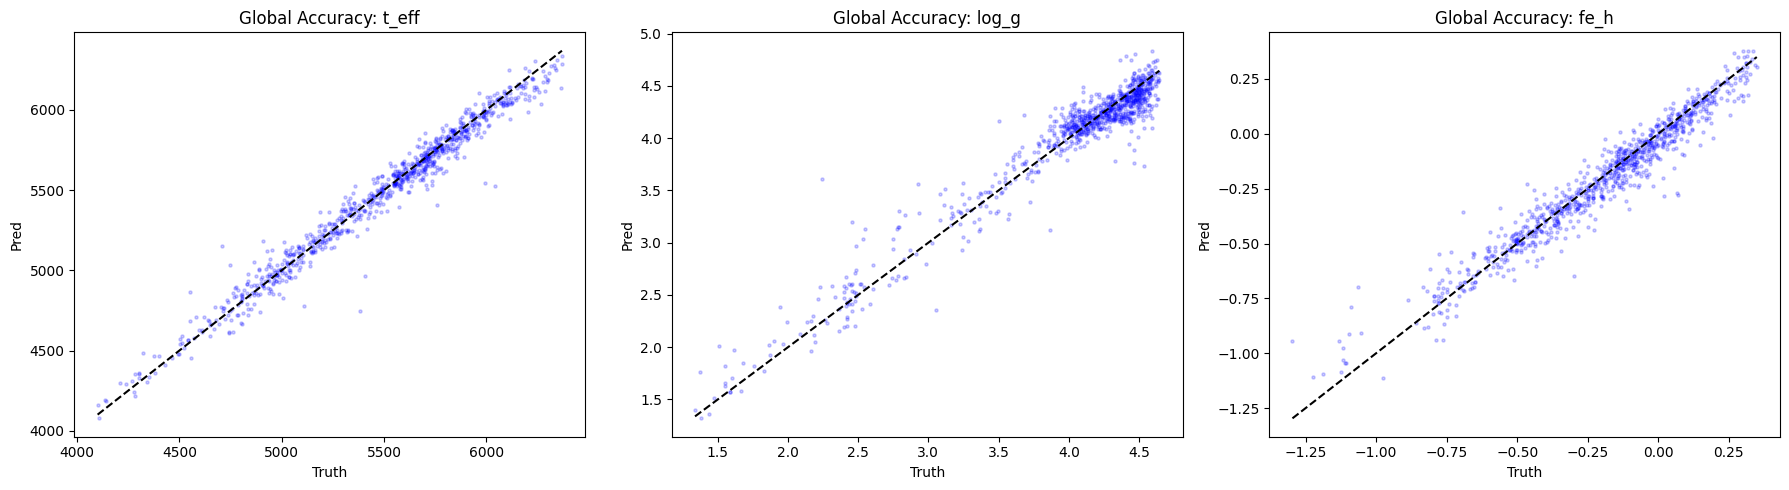


Uncertainty Correlation Matrices (T_eff, log_g, [Fe/H]) for DIAGONAL_GAUSSIAN:


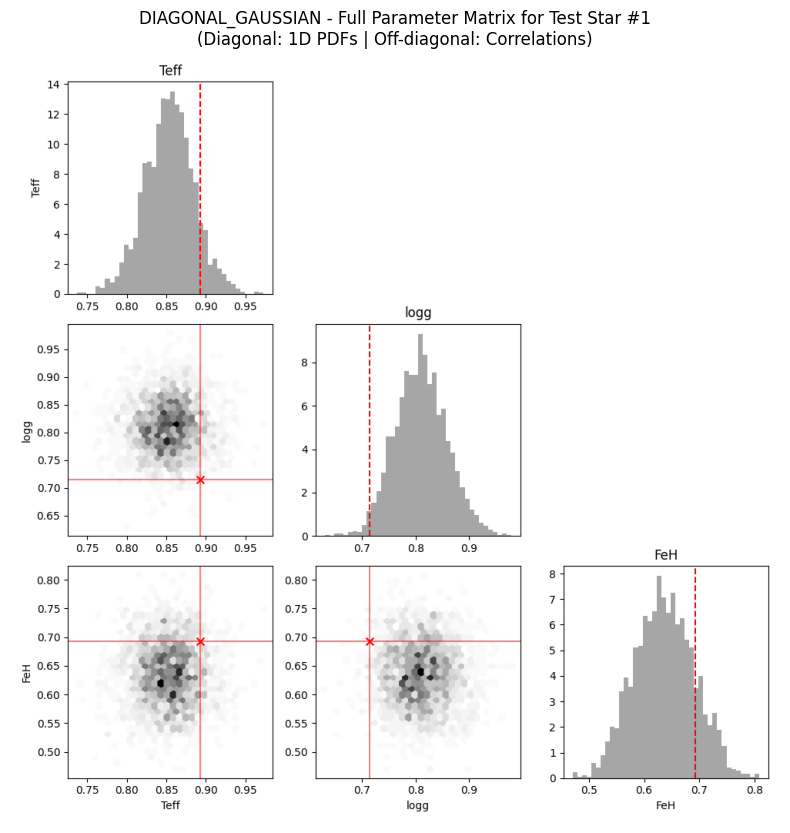

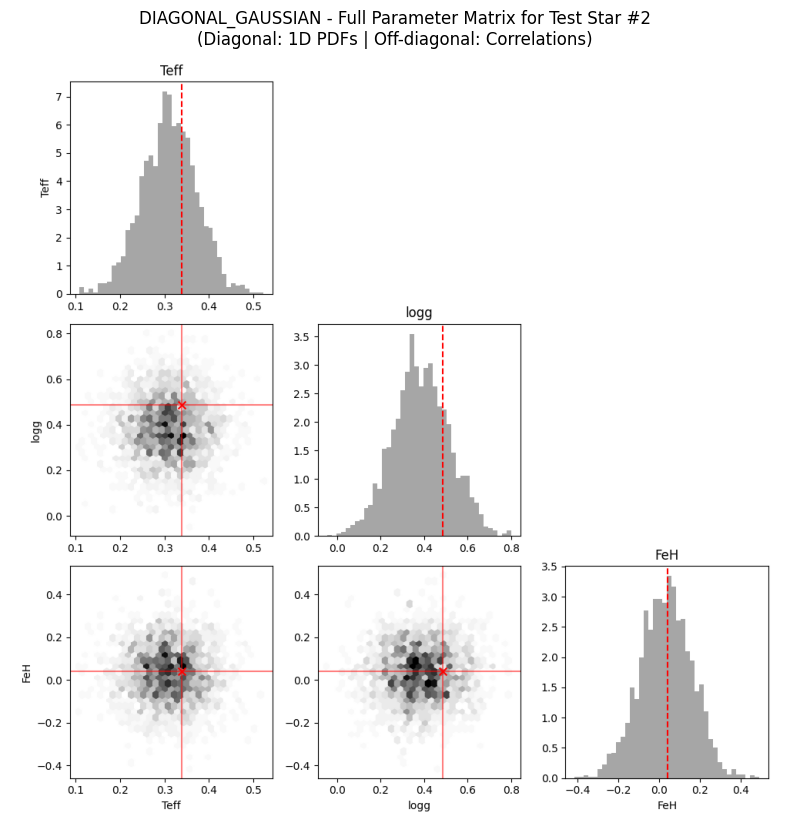

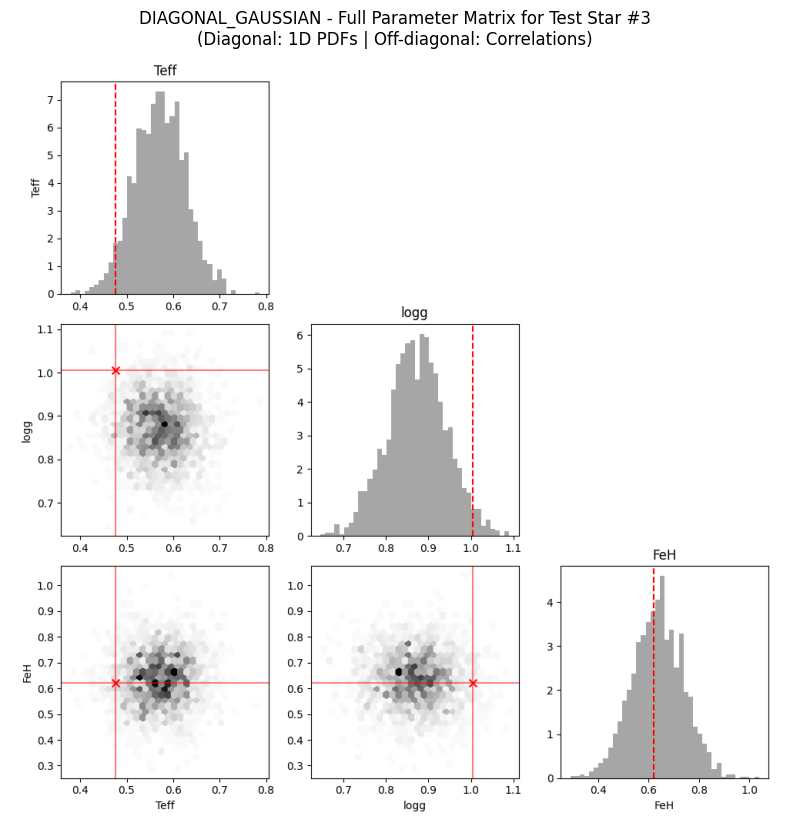


MODEL ARCHITECTURE: FULL_GAUSSIAN


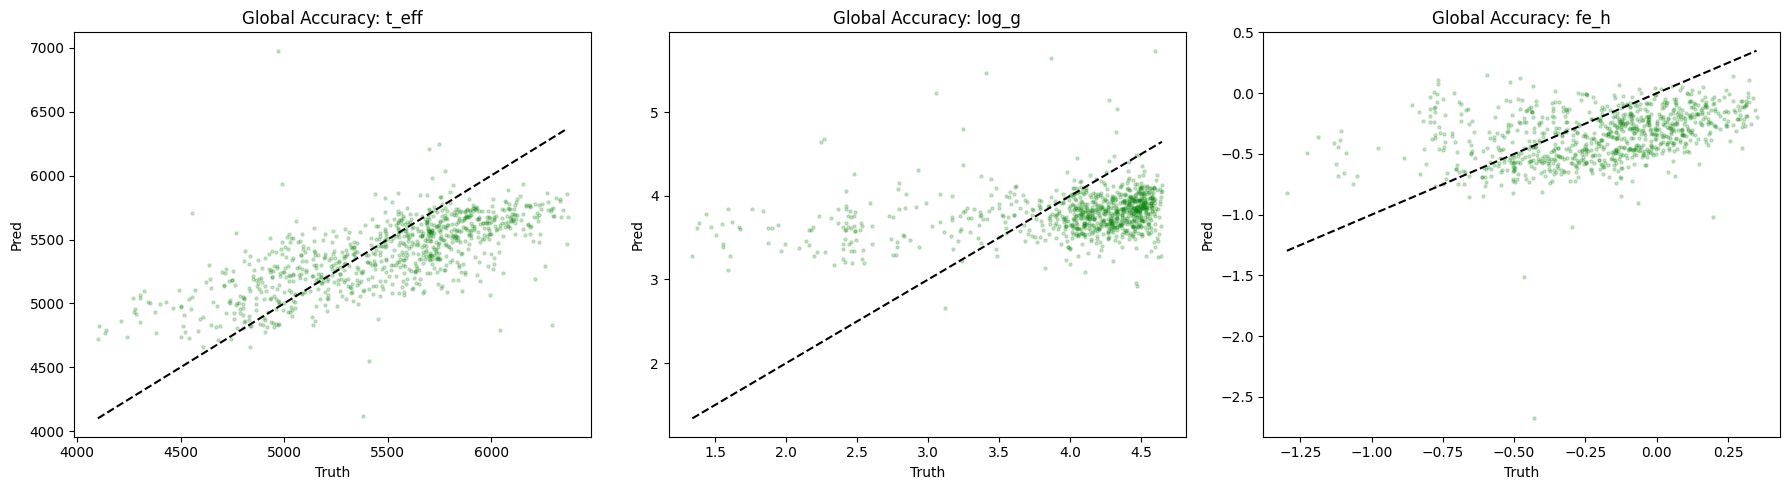


Uncertainty Correlation Matrices (T_eff, log_g, [Fe/H]) for FULL_GAUSSIAN:


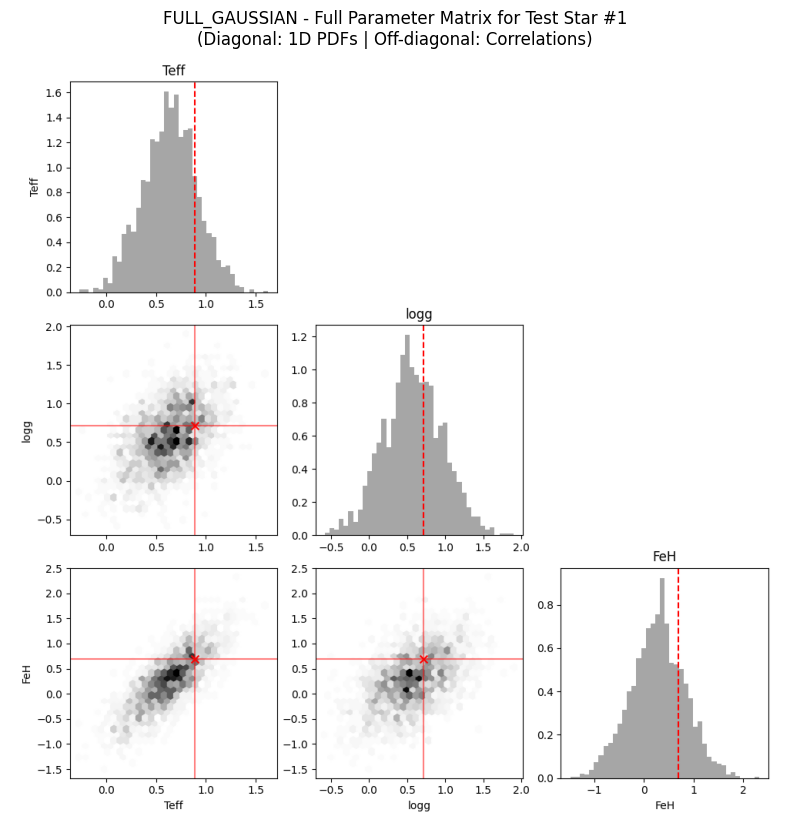

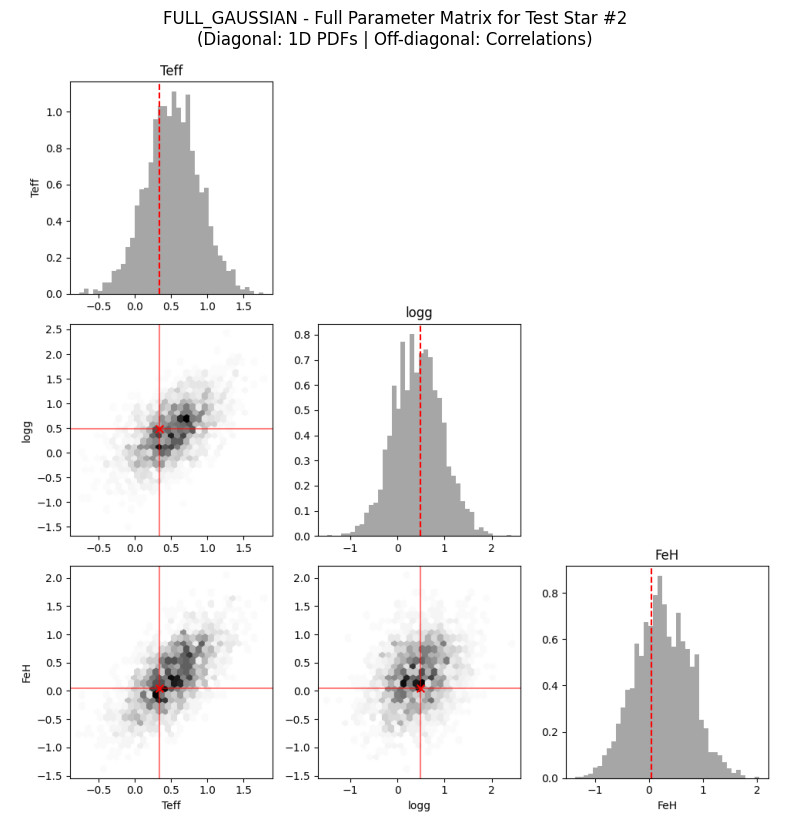

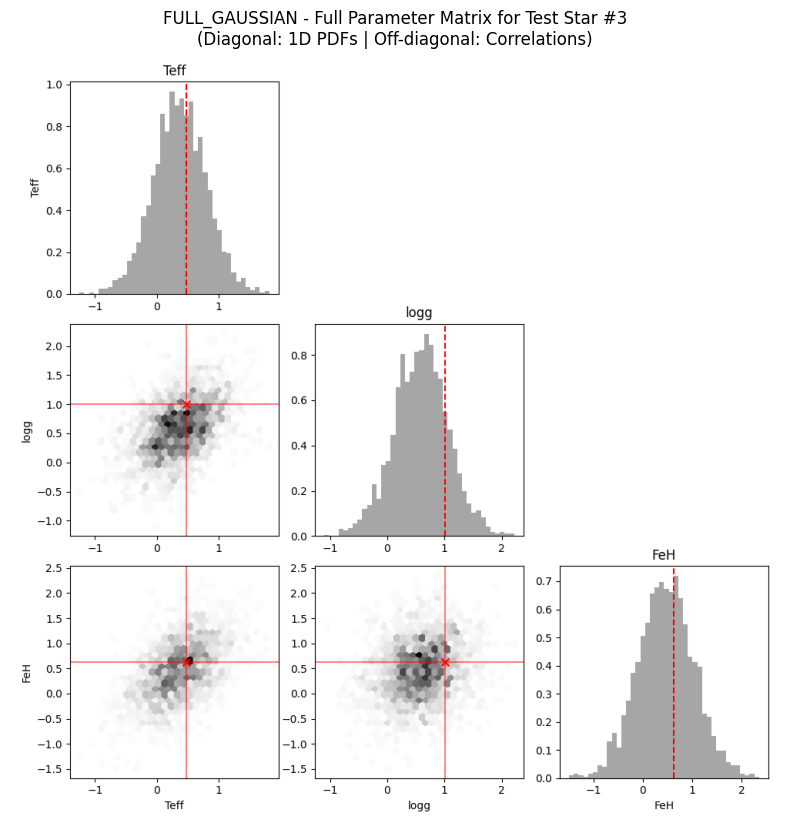


MODEL ARCHITECTURE: FULL_FLOW


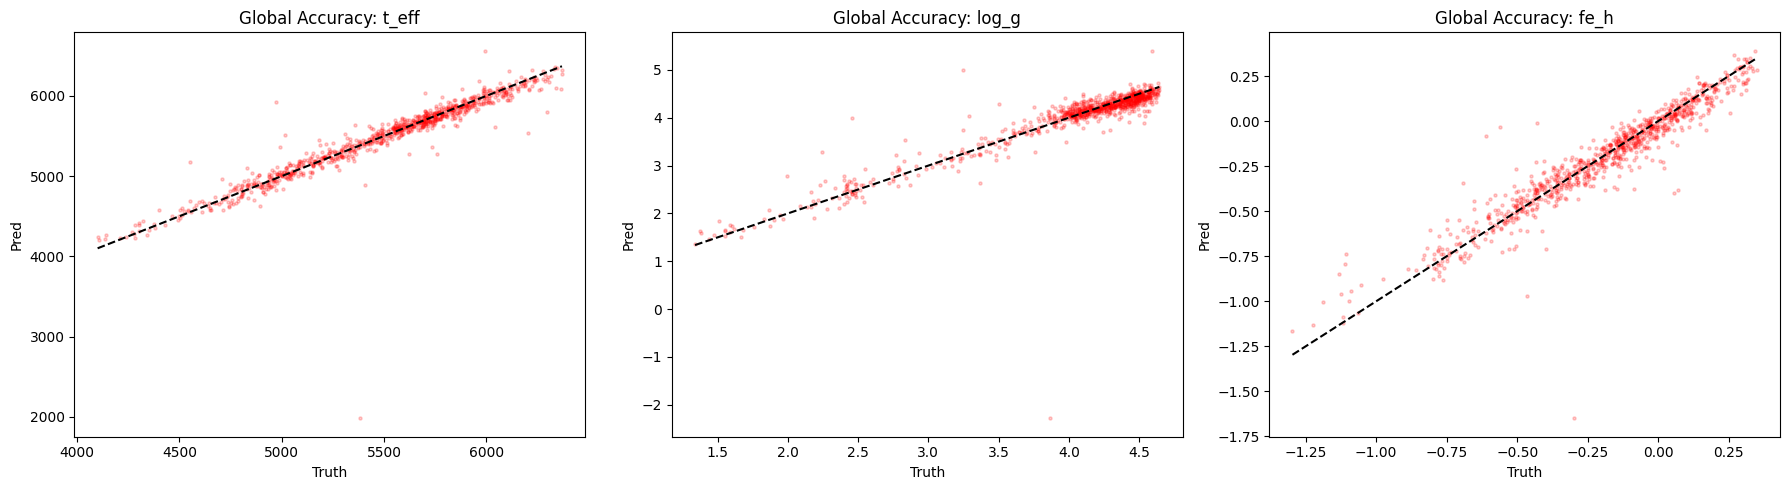


Uncertainty Correlation Matrices (T_eff, log_g, [Fe/H]) for FULL_FLOW:


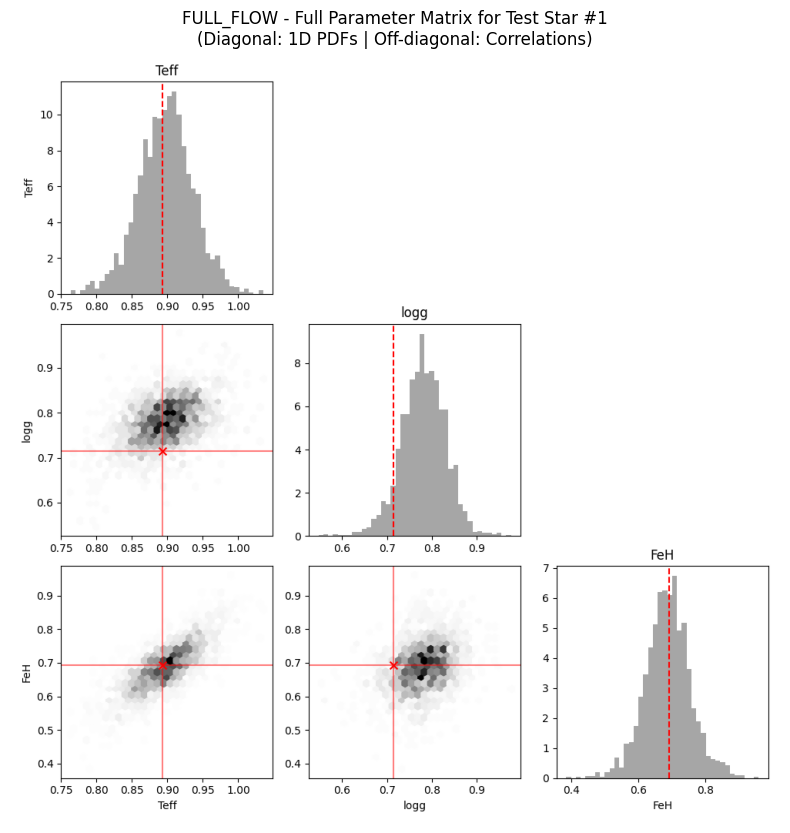

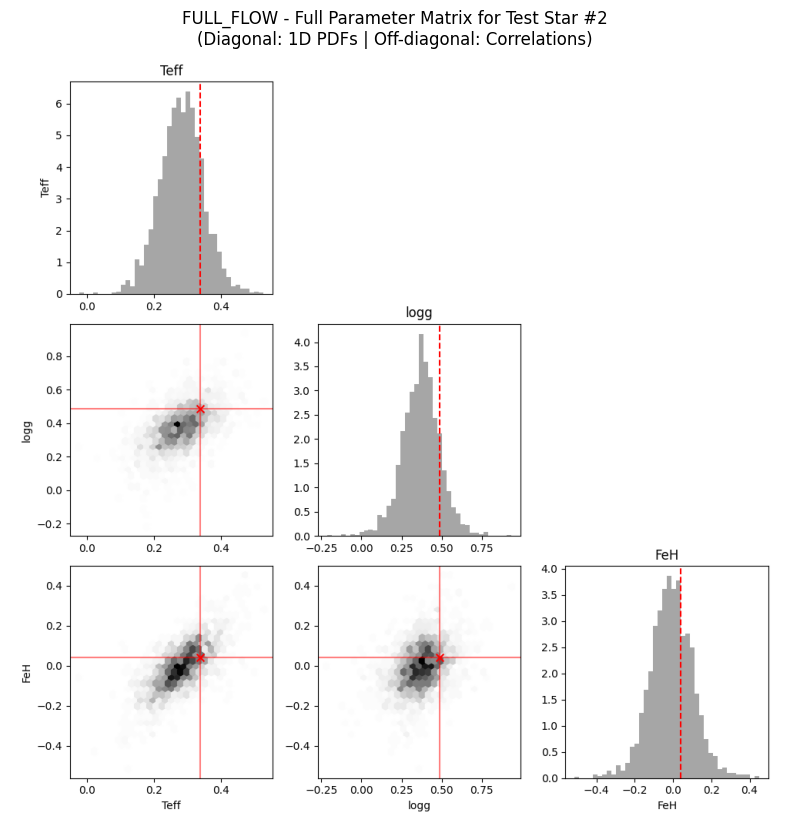

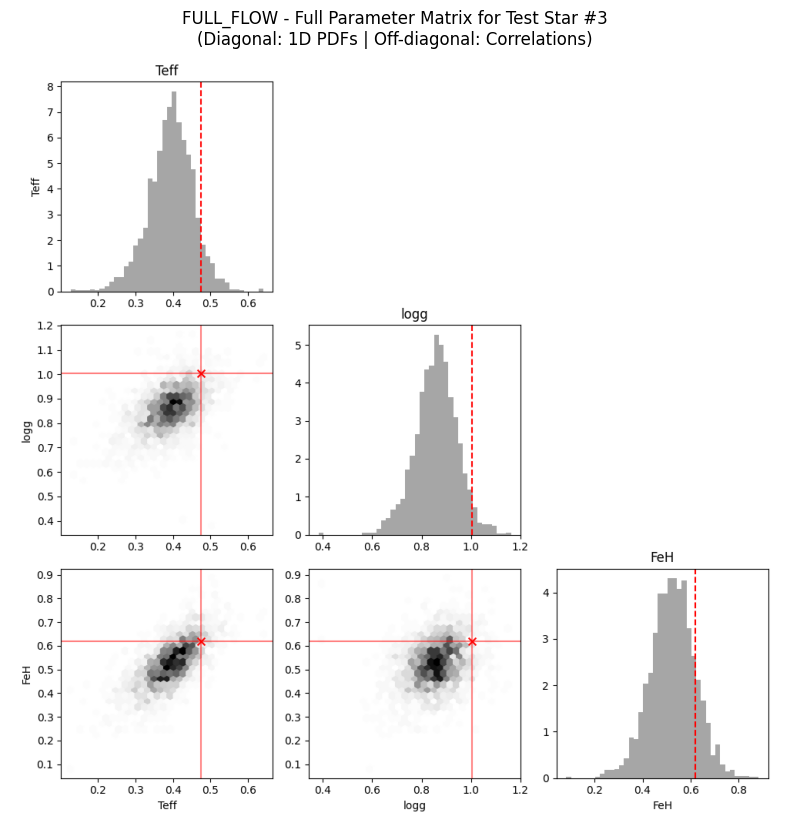

In [7]:

# Color mapping for models
colors_map = {'diagonal_gaussian': 'blue', 'full_gaussian': 'green', 'full_flow': 'red'}

# Loop through each model to display performance and diagnostics
for flow_type in flow_types:
    if flow_type in results:
        print(f"\n{'='*100}")
        print(f"MODEL ARCHITECTURE: {flow_type.upper()}")
        print(f"{'='*100}")

        p_m = results[flow_type]['p_means']
        t_p = results[flow_type]['truths_phys']

        # Global Scatter Plots
        fig_scat, axes = plt.subplots(1, 3, figsize=(18, 5))
        for i, name in enumerate(labelNames):
            axes[i].scatter(t_p[:, i], p_m[:, i], alpha=0.2, s=5, color=colors_map.get(flow_type, 'blue'))
            axes[i].plot([t_p[:, i].min(), t_p[:, i].max()], [t_p[:, i].min(), t_p[:, i].max()], 'k--')
            axes[i].set_title(f'Global Accuracy: {name}')
            axes[i].set_xlabel('Truth')
            axes[i].set_ylabel('Pred')
        plt.tight_layout()
        plt.show()

        # Local Diagnostic 3x3 Matrices
        print(f"\nUncertainty Correlation Matrices (T_eff, log_g, [Fe/H]) for {flow_type.upper()}:")
        for star_idx in range(3):
            img_path = f'nf_plots_all/{flow_type}_star_{star_idx}.png'
            if os.path.exists(img_path):
                plt.figure(figsize=(10, 10))
                img = mpimg.imread(img_path)
                plt.imshow(img)
                plt.axis('off')
                plt.title(f"{flow_type.upper()} - Full Parameter Matrix for Test Star #{star_idx+1}\n(Diagonal: 1D PDFs | Off-diagonal: Correlations)", fontsize=12)
                plt.show()
            else:
                print(f"Diagnostic plot missing for {flow_type} Star {star_idx}")

### Explanation of the 3x3 Uncertainty Matrices

The figures above show the predicted probability density function (PDF) for an example stellar spectrum measurement:

*   **Diagonal (top-left to bottom-right):** These plots show the 1D marginal distributions (histograms) for the parameters: Effective Temperature ($T_{\text{eff}}$), Surface Gravity ($\log g$), and Metallicity ([Fe/H]). The width of these curves represents the model's uncertainty for each individual parameter.
*   **Lower Triangle:** The hexbin plots visualize the correlations between pairs of parameters. An inclined elliptical shape indicates that the model has identified a dependency between the errors of different parameters (e.g., between temperature and gravity).
*   **Red Markings:** The red 'X' or dashed lines represent the 'Ground Truth' (the true value). A high-performing model should place this value within the high-density (darker) regions of its prediction.

### Vergleich der Modelle: Prediction vs Truth & PDF Visualisierungen
Hier werden die Ergebnisse für alle drei Flow-Typen nacheinander visualisiert.

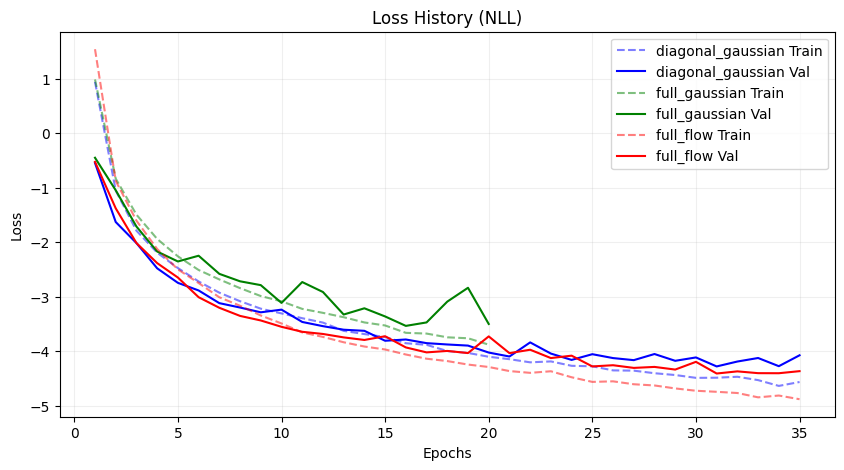

In [12]:

# Plotting Train vs Validation Loss
plt.figure(figsize=(10, 5))
colors = {'diagonal_gaussian': 'blue', 'full_gaussian': 'green', 'full_flow': 'red'}

for flow_type in flow_types:
    if flow_type in results:
        epochs = range(1, len(results[flow_type]['train_losses']) + 1)
        plt.plot(epochs, results[flow_type]['train_losses'], '--', color=colors[flow_type], alpha=0.5, label=f'{flow_type} Train')
        plt.plot(epochs, results[flow_type]['val_losses'], '-', color=colors[flow_type], label=f'{flow_type} Val')

plt.title('Loss History (NLL)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()



### Summary of Uncertainty Quantification
A Pull Standard Deviation of approximately 1.0 indicates that the model's predicted uncertainties match the actual residuals. Values significantly lower than 1.0 mean the model is 'over-conservative' (predicting larger errors than actual), while values higher than 1.0 mean the model is 'over-confident'.